# Multitemporal Burnt Area Analysis (dNBR)

This notebook converts the Sentinel Hub
[Multitemporal Burnt Area Analysis](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/burned_area/)
evalscript by **FC Basson**, improved by **Pierre Markuse**, into a reusable
openEO User-Defined Process (UDP).

Mapping a burn scar from a single image is unreliable, because dark soil, water,
shadow and recently ploughed fields all look a bit like char. Comparing the same
pixel *before* and *after* the fire removes everything that was already dark, and
turns "is this burnt?" into "did this change in the way burning changes things?".
That difference — **dNBR** — is the standard basis for burn severity mapping.

## Overview

In this notebook we will:

1. Connect to an openEO backend serving Sentinel-2 L2A
2. Load a **pre-fire** and a **post-fire** acquisition of the same scene
3. Merge them into one cube, resolving the NIR/SWIR band-name collision
4. Compute NBR on each date, difference them, and classify severity into three levels
5. Verify the whole classification against a numpy reimplementation
6. Run the full scene and visualise it
7. Re-run the same graph on three fires
8. Export the process graph as a parameterised UDP

## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/burned_area/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)

## Scientific Background

### The Normalized Burn Ratio

Healthy vegetation reflects strongly in the near infrared (B08, 842 nm) because
of the internal structure of leaf mesophyll, and absorbs in the short-wave
infrared (B12, 2190 nm) because of its water content. Fire destroys both
properties at once: the canopy structure collapses, the water is driven off, and
what remains is char and ash. NIR therefore falls while SWIR rises, which is why
the **Normalized Burn Ratio** separates burnt from unburnt so cleanly:

$$\text{NBR} = \frac{B08 - B12}{B08 + B12}$$

The original guards the division explicitly — returning 0 when `B08 + B12 == 0`
— and this conversion keeps that guard.

### Differencing the two dates

$$\text{dNBR} = \text{NBR}_\text{pre} - \text{NBR}_\text{post}$$

Because NBR is high before the fire and low after it, dNBR is **positive** over
burnt ground and near zero everywhere unchanged. Differencing also cancels the
static confusers: a lake is dark on both dates, so its dNBR is ~0 no matter how
low its NBR is. This is the same logic USGS/USFS use in their operational burn
severity product (Key & Benson, 2006), whose severity classes the thresholds
below approximate.

### The three severity classes

The output is a natural-colour view of the **post-fire** scene, tinted by
severity. The colour is built from the post-fire bands with a mild stretch:

```
stretch(v) = (v - 0.05) / (1.00 - 0.05)
R = stretch(2.8·B04 + 0.10·B05)
G = stretch(2.8·B03 + 0.15·B08)
B = stretch(2.8·B02)
```

The small B05 and B08 admixtures in red and green are a cosmetic touch from
Pierre Markuse's revision — they lift vegetation slightly and give the unburnt
background a more natural look than a plain RGB stretch.

| dNBR | Class | Output | Appearance |
| --- | --- | --- | --- |
| `< 0.27` | unburned | `[R, G, B]` | plain natural colour |
| `0.27 – 0.66` | moderate | `[R+0.5, G+0.5, B]` | yellow tint (red *and* green raised) |
| `>= 0.66` | severe | `[R+0.5, G, B]` | red tint (only red raised) |

Note that blue is never modified, and that both burnt classes raise red by the
same amount — the *only* thing distinguishing moderate from severe is whether
green is also raised. That collapses the rendering to a natural → yellow → red
ramp.

### Choosing the two dates

Both acquisitions must be as cloud-free as possible: cloud or its shadow on
either date corrupts NBR there and produces spurious severity. They should also
be close enough in season that normal phenology does not itself move NBR — a
pre-fire image from peak greenness compared against a post-fire image after
harvest will flag farmland as burnt. Every date in the parameter file was checked
against the CDSE STAC catalogue for cloud cover.

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing,
visualization, and parameter management.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from matplotlib.patches import Patch
from openeo.processes import array_create, if_

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "multitemporal_burnt_area"

# Initialize parameter manager
param_manager = ParameterManager("multitemporal_burnt_area.params.py")

# Display available options using the built-in helper
param_manager.print_options("multitemporal burnt area (dNBR) algorithm")

Available parameter sets for multitemporal burnt area (dNBR) algorithm:
  1. knysna_south_africa_2017: Knysna, South Africa (June 2017 fires)
  2. pedrogao_grande_portugal_2017: Pedrógão Grande, Portugal (June 2017 fire)
  3. corbieres_aude_france_2025: Corbières, Aude, France (August 2025 fire)

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# Keep the endpoint in a variable so the pre-fire band list can be routed through
# the SAME endpoint mapper as the post-fire one.
_endpoint = "copernicus_dataspace"
_primary_set = "knysna_south_africa_2017"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=_endpoint,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: knysna_south_africa_2017
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Knysna, South Africa (June 2017 fires)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  collection: sentinel-2-l2a -> SENTINEL2_L2A
  bands: ['b02', 'b03', 'b04', 'b05', 'b08', 'b12'] -> ['B02', 'B03', 'B04', 'B05', 'B08', 'B12']


## Load the Two Acquisitions

Two `load_collection` calls differing only in their temporal extent — and in how
many bands they need. The **post-fire** cube carries the full band set, because
the natural-colour rendering is built entirely from the post-fire image; the
**pre-fire** cube only ever contributes its NBR, so NIR and SWIR suffice. Asking
for two bands instead of six on the pre-fire date is a real saving on a
synchronous request.

`bounding_box`, `time_pre`, `time_post` and `cloud_cover` stay as **`Parameter`
objects** so the exported graph keeps its `{"from_parameter": ...}` references and
remains a reusable UDP. Each one-day window is reduced over time with `mean`,
which is an identity for the single acquisition it contains but correctly mosaics
two adjacent granules of the same pass.

In [4]:
bbox = current_params["bounding_box"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE

# Route the pre-fire band list through the same endpoint mapper so the canonical
# ids resolve to this backend's native names.
_pre = param_manager.apply_endpoint_mapping(
    {"collection": current_params["collection"], "bands": current_params["pre_bands"]},
    _endpoint,
)


def load_s2(temporal_extent, band_list):
    """Load one Sentinel-2 acquisition and collapse its window to a single slice."""
    return connection.load_collection(
        current_params["collection"].default,
        temporal_extent=temporal_extent,
        spatial_extent=bbox,
        bands=band_list,
        properties={
            "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"],
        },
    ).reduce_dimension(dimension=time_dim, reducer="mean")


post_cube = load_s2(current_params["time_post"], current_params["bands"].default)
pre_cube = load_s2(current_params["time_pre"], _pre["bands"].default)

print(f"Post-fire bands: {current_params['bands'].default}")
print(f"Pre-fire  bands: {_pre['bands'].default}")
print("✅ Loaded the pre-fire and post-fire acquisitions")

Post-fire bands: ['B02', 'B03', 'B04', 'B05', 'B08', 'B12']
Pre-fire  bands: ['B08', 'B12']
✅ Loaded the pre-fire and post-fire acquisitions


## Merge the Pair into One Cube

Both cubes expose `B08` and `B12`, which would collide on merge, so the two
pre-fire bands are relabelled: `.band(...)` drops the bands dimension and
`add_dimension` re-attaches it under a distinct label. The post-fire cube keeps
its native names. (`rename_labels` would be more direct but is unavailable on
CDSE.)

The original solved the same problem with `mosaicking: "ORBIT"` and a
`preProcessScenes` filter, reading the two dates as `samples[0]` (most recent —
post-fire) and `samples[1]` (pre-fire).

In [5]:
post_bands = param_manager.band_name_map(current_params)
pre_names = dict(
    zip(current_params["pre_bands"].default, _pre["bands"].default, strict=True)
)

# Relabel the pre-fire NIR/SWIR pair so it cannot collide with its post-fire twin.
pre_relabelled = (
    pre_cube.band(pre_names["b08"])
    .add_dimension(name=bands_dim, label="pre_b08", type="bands")
    .merge_cubes(
        pre_cube.band(pre_names["b12"])
        .add_dimension(name=bands_dim, label="pre_b12", type="bands")
    )
)

fire_pair = post_cube.merge_cubes(pre_relabelled)

EXPECTED_BANDS = [
    post_bands["b02"], post_bands["b03"], post_bands["b04"],
    post_bands["b05"], post_bands["b08"], post_bands["b12"],
    "pre_b08", "pre_b12",
]

fused_bands = fire_pair.metadata.band_names
print("Fused band order:", fused_bands)
assert fused_bands == EXPECTED_BANDS, f"expected {EXPECTED_BANDS}, got {fused_bands}"

Fused band order: ['B02', 'B03', 'B04', 'B05', 'B08', 'B12', 'pre_b08', 'pre_b12']


## Compute dNBR and Classify Severity

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel`. openEO has no early `return`, so the three-way classification is
expressed as nested `if_` calls.

Two simplifications fall out of reading the original's three output vectors side
by side: **blue is identical in all three classes**, and **red is raised by 0.5
in both burnt classes**. Only green distinguishes moderate from severe. Writing
it that way is exactly equivalent and much easier to check.

In [6]:
# Thresholds, gains and stretch bounds, verbatim from the original evalscript.
STRETCH_MIN, STRETCH_MAX = 0.05, 1.00
DNBR_MODERATE = 0.27  # below this: unburned
DNBR_SEVERE = 0.66  # at or above this: severe


def burn_severity(data):
    """dNBR severity classification over the post-fire natural-colour render."""
    # Bands in EXPECTED_BANDS order; S2 reflectance -> 0-1.
    b02, b03, b04, b05, b08, b12 = (data[i] / scale for i in range(6))
    pre_b08, pre_b12 = data[6] / scale, data[7] / scale

    # NBR on each date, guarding the zero denominator exactly as the original does.
    denom_pre = pre_b08 + pre_b12
    denom_post = b08 + b12
    nbr_pre = if_(denom_pre == 0, 0.0, (pre_b08 - pre_b12) / denom_pre)
    nbr_post = if_(denom_post == 0, 0.0, (b08 - b12) / denom_post)
    dnbr = nbr_pre - nbr_post

    def stretch(value):
        return (value - STRETCH_MIN) / (STRETCH_MAX - STRETCH_MIN)

    # Natural-colour rendering of the POST-fire scene.
    red = stretch(2.8 * b04 + 0.1 * b05)
    green = stretch(2.8 * b03 + 0.15 * b08)
    blue = stretch(2.8 * b02)

    unburned = dnbr < DNBR_MODERATE

    # Both burnt classes raise red by 0.5; only moderate also raises green;
    # blue is untouched in all three classes.
    out_red = if_(unburned, red, red + 0.5)
    out_green = if_(unburned, green, if_(dnbr < DNBR_SEVERE, green + 0.5, green))

    return array_create([out_red, out_green, blue])


burn_rgb = fire_pair.apply_dimension(dimension=bands_dim, process=burn_severity)

# The evalscript emits 0-1 floats that Sentinel Hub renders as 8-bit RGB;
# linear_scale_range does the same here and clips the out-of-range values that
# the +0.5 severity offsets deliberately produce.
burn_rgb = burn_rgb.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)

burn_result = burn_rgb.save_result("GTiff")

## Verify the Classification

**This runs before the full-scene request on purpose**, so a problem costs a
small window rather than a whole scene.

The check reproduces the entire computation — both NBRs, the difference, the
stretch and the three-way classification — in numpy from the raw fused bands, and
compares it against what the backend returned. This matters more than a spot
check on the arithmetic: a misassigned severity class shifts a channel by
`0.5 × 255 ≈ 127` DN, so bounding the deviation at 1 DN proves every pixel landed
in the same class the reference implementation chose.

CDSE **truncates** when writing the integer raster, so the exact expected value
is `floor(clip(x, 0, 1) × 255)`.

In [7]:
_bb = current_params["bounding_box"].default
_cx = (_bb["west"] + _bb["east"]) / 2
_cy = (_bb["south"] + _bb["north"]) / 2
check_bbox = {
    "west": round(_cx - 0.03, 4),
    "east": round(_cx + 0.03, 4),
    "south": round(_cy - 0.02, 4),
    "north": round(_cy + 0.02, 4),
}


def build_fire_pair(extent, params, pre_spec):
    """Build the fused 8-band cube for an explicit extent (same steps as above)."""
    def _load(temporal_extent, band_list):
        return connection.load_collection(
            params["collection"].default,
            temporal_extent=temporal_extent,
            spatial_extent=extent,
            bands=band_list,
            properties={"eo:cloud_cover": lambda x: x <= params["cloud_cover"]},
        ).reduce_dimension(dimension=time_dim, reducer="mean")

    _post = _load(params["time_post"], params["bands"].default)
    _pre_cube = _load(params["time_pre"], pre_spec["bands"].default)
    _names = dict(
        zip(params["pre_bands"].default, pre_spec["bands"].default, strict=True)
    )
    _relabelled = (
        _pre_cube.band(_names["b08"])
        .add_dimension(name=bands_dim, label="pre_b08", type="bands")
        .merge_cubes(
            _pre_cube.band(_names["b12"])
            .add_dimension(name=bands_dim, label="pre_b12", type="bands")
        )
    )
    return _post.merge_cubes(_relabelled)


check_pair = build_fire_pair(check_bbox, current_params, _pre)

# cloud_cover is still a Parameter ref and synchronous execution rejects
# unresolved refs, so resolve both cubes before downloading.
_raw = check_pair.save_result("GTiff")
param_manager.resolve(_raw, current_params).download("burnt_area_check_fused.tif")

_comp = check_pair.apply_dimension(
    dimension=bands_dim, process=burn_severity
).linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
).save_result("GTiff")
param_manager.resolve(_comp, current_params).download("burnt_area_check_rgb.tif")

print("✅ Downloaded validation window:", check_bbox)

✅ Downloaded validation window: {'west': 23.045, 'east': 23.105, 'south': -34.01, 'north': -33.97}


In [8]:
def _read(path):
    da = rioxarray.open_rasterio(path)
    arr = da.values.astype("float64")
    if da.rio.nodata is not None and np.isfinite(da.rio.nodata):
        arr[arr == da.rio.nodata] = np.nan
    return arr


f = _read("burnt_area_check_fused.tif")
comp = _read("burnt_area_check_rgb.tif")
valid = np.all(np.isfinite(f), axis=0) & np.all(np.isfinite(comp), axis=0)
print(f"comparable pixels: {valid.mean():.2%}")

b02, b03, b04, b05, b08, b12 = (f[i] / scale for i in range(6))
pre_b08, pre_b12 = f[6] / scale, f[7] / scale

# Sanity: reflectance must land in 0-1 after scaling, else reflectance_scale is wrong.
_p99 = float(np.nanpercentile(b04[valid], 99))
assert 0 <= _p99 <= 1.5, (
    f"B04 99th percentile is {_p99:.2f} after dividing by reflectance_scale={scale}; "
    "expected roughly 0-1 reflectance. NBR and the colour stretch would both be wrong."
)

# Reproduce NBR, dNBR and the classification.
denom_pre, denom_post = pre_b08 + pre_b12, b08 + b12
nbr_pre = np.where(denom_pre == 0, 0.0, (pre_b08 - pre_b12) / np.where(denom_pre == 0, 1, denom_pre))
nbr_post = np.where(denom_post == 0, 0.0, (b08 - b12) / np.where(denom_post == 0, 1, denom_post))
dnbr = nbr_pre - nbr_post


def _stretch(value):
    return (value - STRETCH_MIN) / (STRETCH_MAX - STRETCH_MIN)


red, green, blue = (
    _stretch(2.8 * b04 + 0.1 * b05),
    _stretch(2.8 * b03 + 0.15 * b08),
    _stretch(2.8 * b02),
)

m_unburned = dnbr < DNBR_MODERATE
m_moderate = (~m_unburned) & (dnbr < DNBR_SEVERE)
m_severe = dnbr >= DNBR_SEVERE

shares = {
    "unburned": m_unburned[valid].mean(),
    "moderate": m_moderate[valid].mean(),
    "severe": m_severe[valid].mean(),
}
print("Severity classes in the validation window:")
for name, share in shares.items():
    print(f"  {name:<10} {share:6.1%}")
assert abs(sum(shares.values()) - 1.0) < 1e-9, "classes must partition the scene"

want = np.stack([
    np.where(m_unburned, red, red + 0.5),
    np.where(m_unburned, green, np.where(m_moderate, green + 0.5, green)),
    blue,
])

for channel in range(3):
    expected = np.floor(np.clip(want[channel], 0, 1) * 255)
    deviation = np.abs(comp[channel][valid] - expected[valid])
    exact = np.mean(comp[channel][valid] == expected[valid])
    print(f"channel {'RGB'[channel]}: exact {exact:.4%}, max deviation {deviation.max():g} DN")
    # A misclassified pixel would shift the channel by 0.5*255 = 127 DN, so this
    # bound proves the severity classes agree; the sub-DN residue is float32
    # quantisation at integer boundaries.
    assert deviation.max() <= 1, f"channel {'RGB'[channel]} deviates by {deviation.max()} DN"
    assert exact > 0.999, f"channel {'RGB'[channel]} exact-match rate only {exact:.4%}"

print("✅ openEO reproduces the dNBR classification, class for class")

comparable pixels: 100.00%
Severity classes in the validation window:
  unburned    88.9%
  moderate     9.0%
  severe       2.1%
channel R: exact 99.9996%, max deviation 1 DN
channel G: exact 100.0000%, max deviation 0 DN
channel B: exact 100.0000%, max deviation 0 DN
✅ openEO reproduces the dNBR classification, class for class


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


## Execute and Download

In [9]:
_location_slug = (
    current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")
)
rgb_filename = f"{_algorithm_id}_{_location_slug}.tif"

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialise them here. `burn_result` itself keeps them for the UDP export.
param_manager.resolve(burn_result, current_params).download(rgb_filename)
print(f"✅ Downloaded {rgb_filename}")

# Coverage report. A Sentinel-2 AOI near the edge of a relative orbit's swath is
# only partly imaged on that orbit's dates — and the granule can still report 0%
# cloud, so selecting dates on cloud alone will happily pick one that leaves most
# of the AOI empty. Check this explicitly rather than discovering it in the plot.
_da = rioxarray.open_rasterio(rgb_filename)
_nodata_frac = (
    float(np.mean(np.all(_da.values == _da.rio.nodata, axis=0)))
    if _da.rio.nodata is not None
    else 0.0
)
print(f"no-data: {_nodata_frac:.2%} of the scene")
if _nodata_frac > 0.05:
    print(
        f"⚠️  {_nodata_frac:.0%} of the AOI is empty. The most likely cause is that "
        "one of the two dates falls on a relative orbit whose swath only clips this "
        "AOI. Check per-date coverage in the STAC catalogue and prefer a pre/post "
        "pair from the same, fully-covering relative orbit."
    )

✅ Downloaded multitemporal_burnt_area_knysna.tif
no-data: 0.64% of the scene


## Visualize the Result

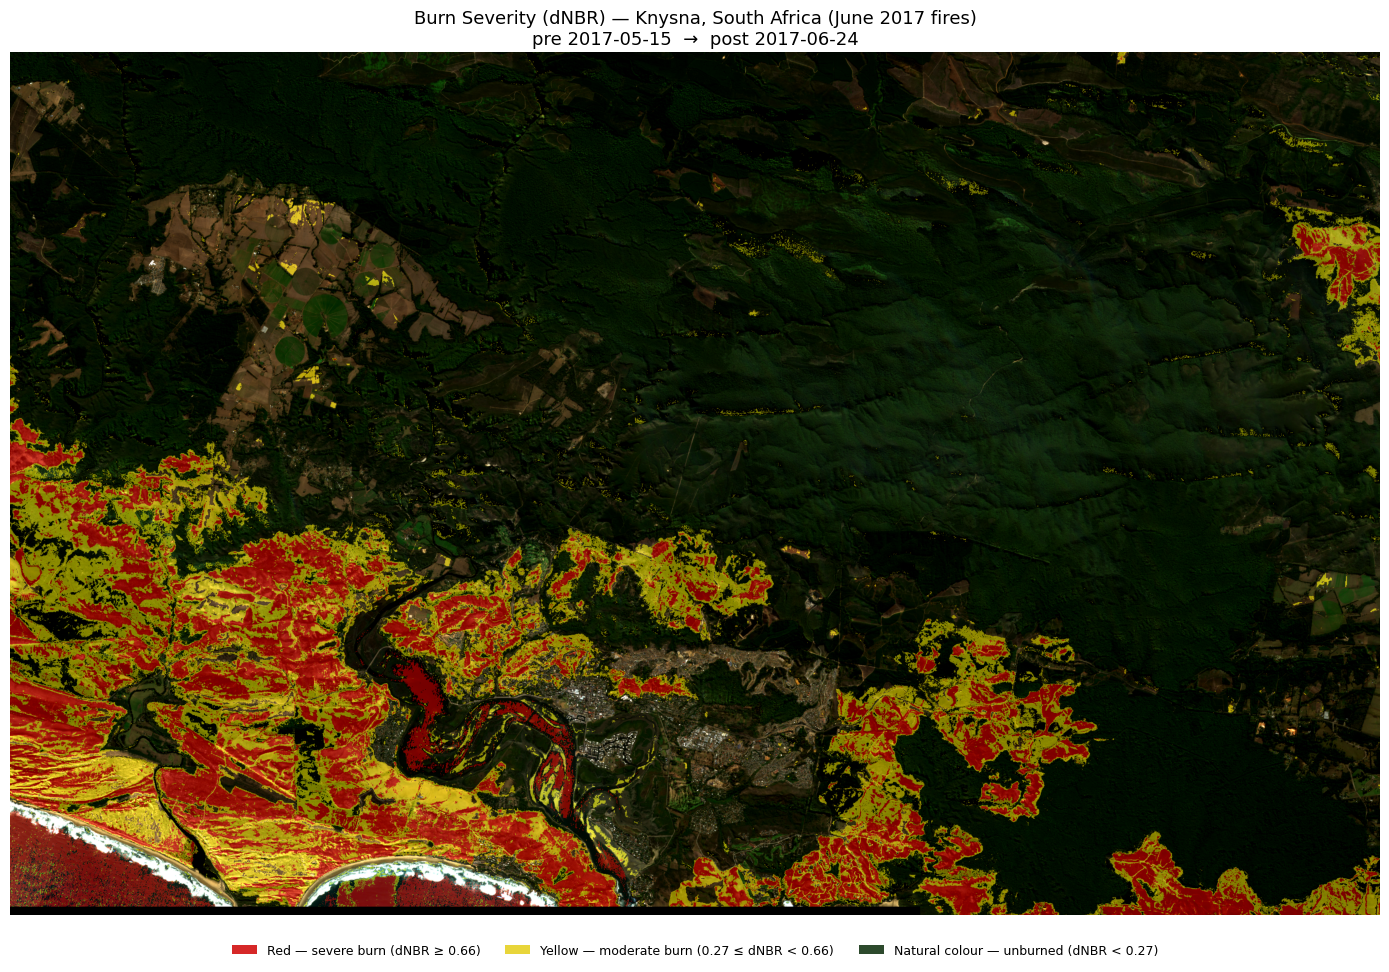

In [10]:
def read_rgb(path):
    """Read a 3-band composite as float RGB in 0-1, with no-data mapped to NaN."""
    da = rioxarray.open_rasterio(path)
    arr = da.values.astype("float32")
    if da.rio.nodata is not None:
        arr[arr == da.rio.nodata] = np.nan
    return np.transpose(arr, (1, 2, 0)) / 255.0


SEVERITY_LEGEND = [
    Patch(facecolor="#d62828", label="Red — severe burn (dNBR ≥ 0.66)"),
    Patch(facecolor="#e8d53a", label="Yellow — moderate burn (0.27 ≤ dNBR < 0.66)"),
    Patch(facecolor="#2d4a2d", label="Natural colour — unburned (dNBR < 0.27)"),
]

rgb = read_rgb(rgb_filename)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(np.nan_to_num(rgb))
ax.set_title(
    f"Burn Severity (dNBR) — {current_params['location_name']}\n"
    f"pre {current_params['time_pre'].default[0]}  →  "
    f"post {current_params['time_post'].default[0]}",
    fontsize=13,
)
ax.axis("off")
ax.legend(
    handles=SEVERITY_LEGEND,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=9,
    frameon=False,
)
plt.tight_layout()
plt.show()

## Validation Across Multiple Fires

The same graph is re-run on the two other parameter sets, in different biomes and
fuel types:

- **Pedrógão Grande, Portugal (June 2017)** — ~45,000 ha of eucalyptus and
  maritime pine, one of the deadliest fires in Portuguese history.
- **Corbières, Aude, France (August 2025)** — ~11,000 ha of Mediterranean
  garrigue and vineyard. Both dates are relative orbit 8; the alternating orbit 51
  clips this AOI to ~15% despite offering several cloud-free dates.

In [11]:
validation_sets = ["pedrogao_grande_portugal_2017", "corbieres_aude_france_2025"]
validation_outputs = {}

for set_name in validation_sets:
    _, val_params = param_manager.quick_connect(
        param_set=set_name, endpoint=_endpoint, silent=True
    )
    val_pre = param_manager.apply_endpoint_mapping(
        {"collection": val_params["collection"], "bands": val_params["pre_bands"]},
        _endpoint,
    )
    val_pair = build_fire_pair(val_params["bounding_box"], val_params, val_pre)
    val_result = val_pair.apply_dimension(
        dimension=bands_dim, process=burn_severity
    ).linear_scale_range(
        input_min=0, input_max=1, output_min=0, output_max=255
    ).save_result("GTiff")

    val_file = f"{_algorithm_id}_{set_name}.tif"
    param_manager.resolve(val_result, val_params).download(val_file)
    validation_outputs[set_name] = (val_file, val_params)
    print(f"✅ {set_name}: {val_file}")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Authenticated using refresh token.
✅ pedrogao_grande_portugal_2017: multitemporal_burnt_area_pedrogao_grande_portugal_2017.tif
Authenticated using refresh token.
✅ corbieres_aude_france_2025: multitemporal_burnt_area_corbieres_aude_france_2025.tif


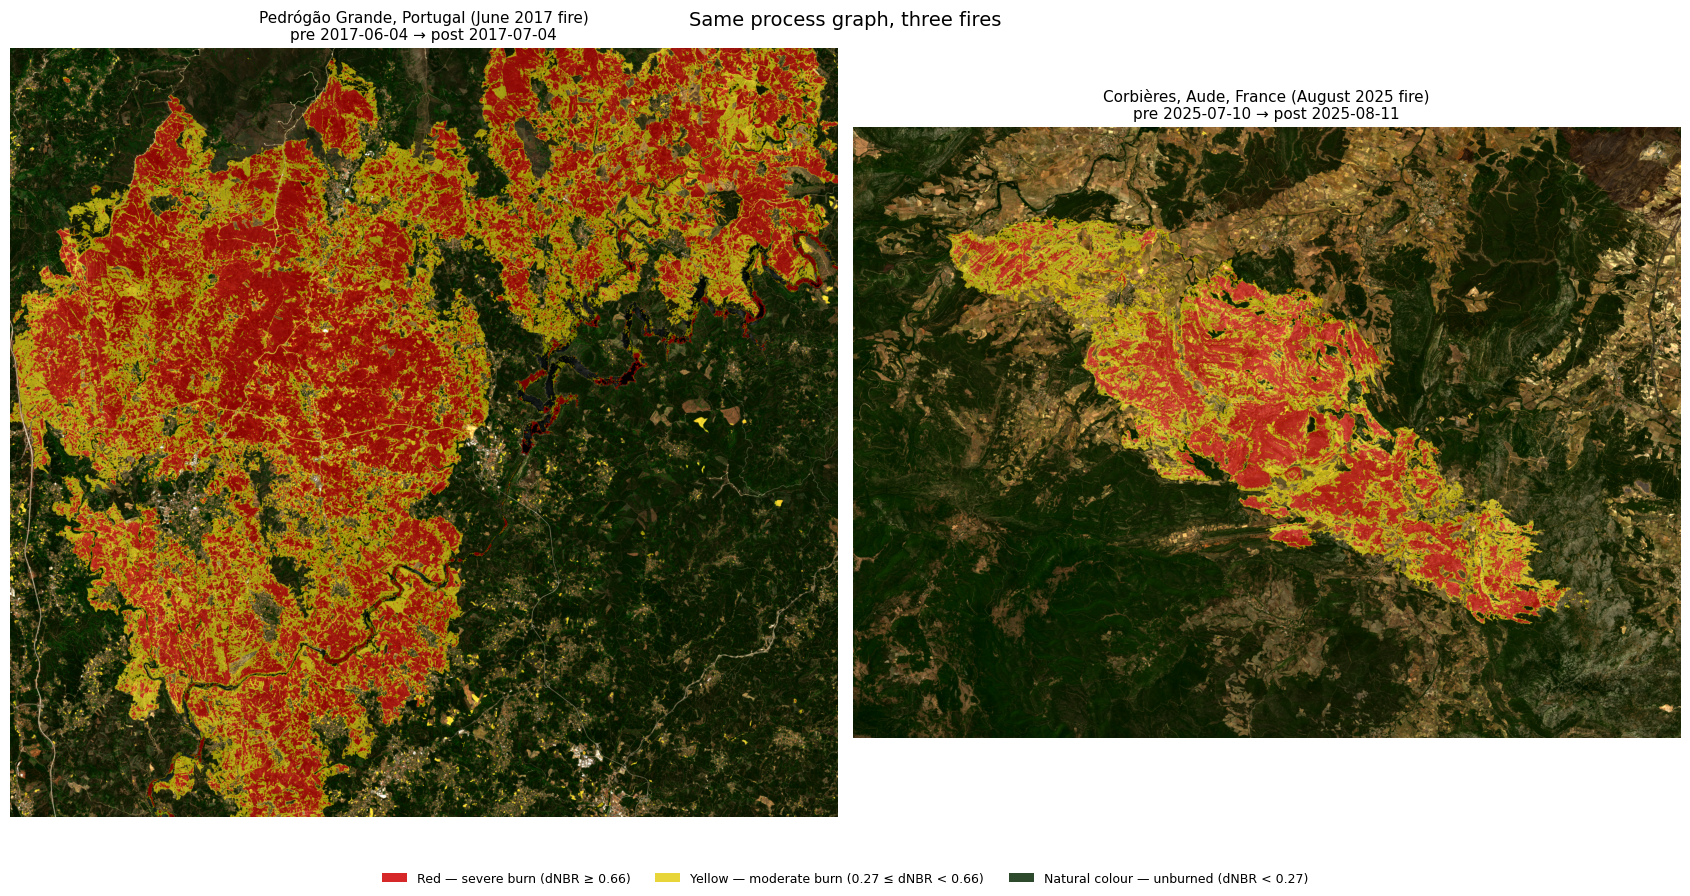

In [12]:
fig, axes = plt.subplots(1, len(validation_outputs), figsize=(17, 9))

for ax, set_name in zip(np.atleast_1d(axes), validation_sets, strict=True):
    val_file, val_params = validation_outputs[set_name]
    ax.imshow(np.nan_to_num(read_rgb(val_file)))
    ax.set_title(
        f"{val_params['location_name']}\n"
        f"pre {val_params['time_pre'].default[0]} → post {val_params['time_post'].default[0]}",
        fontsize=11,
    )
    ax.axis("off")

fig.suptitle("Same process graph, three fires", fontsize=14)
fig.legend(handles=SEVERITY_LEGEND, loc="lower center", ncol=3, fontsize=9, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### What the validation shows

**Knysna** reproduces the original's own example. The burn scar reads as a
coherent red core ringed by yellow along its margins — the expected pattern,
since fire intensity falls off at the perimeter — while the unburnt fynbos and
plantation stay natural dark green and the town of Knysna is clearly visible
inside the scar.

**Pedrógão Grande** and **Corbières** show the same structure in eucalyptus/pine
and in garrigue respectively, which is the point: dNBR is a relative measure, so
it transfers across fuel types without retuning. The Corbières scar is a textbook
wind-driven run: a single elongated NE–SW lobe spreading south-east from the
ignition point near Lagrasse, with a solid severe core and a thin moderate fringe
where the flank fires were held.

Two artefacts are visible and worth naming rather than hiding:

- **Water and surf.** The sea and the Knysna lagoon edge pick up spurious
  severity. NBR is unstable over water — B08 and B12 are both near zero, so the
  ratio is dominated by noise — and tide, sun glint and wave state all change
  between the two dates. The original applies no water mask.
- **Agriculture.** Scattered yellow appears on farmland well outside the fire
  perimeter. Harvest or ploughing between the two dates lowers NBR exactly as
  burning does, so dNBR cannot tell them apart. This is the classic dNBR false
  positive and the main reason operational products pair it with a land-cover
  mask.

### Edge cases

- **Zero denominator.** `B08 + B12 == 0` is guarded explicitly, returning NBR = 0
  rather than a division by zero, matching the original.
- **No-data.** The two dates can have slightly different footprints; edge pixels
  valid on one date but not the other propagate as no-data rather than failing.
  The numerical check compares only pixels valid in all eight bands and reports
  what fraction that was.
- **Out-of-range output.** The `+0.5` severity offsets deliberately push bright
  pixels past 1.0, and `stretch` can go negative over very dark ground.
  `linear_scale_range` clips both ends rather than wrapping.
- **Cloud.** Cloud on either date corrupts that date's NBR and produces arbitrary
  severity. There is no cloud masking in the original beyond scene-level
  `cloud_cover` filtering, so keep the threshold low and check the dates.
- **Partial swath coverage.** Sentinel-2's relative orbits alternate, and an AOI
  near the edge of one orbit's swath is only partly imaged on that orbit's dates.
  Cloud cover gives no warning at all — such a granule frequently reports 0%
  cloud — so a date chosen on cloud alone can leave most of the AOI as no-data and
  the composite mostly empty. Both dates should come from the same relative orbit,
  one that covers the AOI in full; the cell above reports the no-data fraction so
  this shows up as a number rather than only as a disappointing picture.

## Limitations and Differences from the Original

- **Scene selection.** The original used `mosaicking: "ORBIT"` with a
  `preProcessScenes` filter pinning two dates. openEO has no equivalent hook, so
  the same effect comes from two `load_collection` calls over one-day windows
  plus a `mean` reduction. Responsibility for picking two good dates moves to
  whoever fills in the parameters.
- **Severity thresholds are approximations.** `0.27` and `0.66` are a
  three-class simplification of the USGS/USFS dNBR severity table (Key & Benson,
  2006), which defines seven classes. They are not calibrated to any particular
  ecosystem, and burn severity in the radiometric sense is not the same thing as
  ecological severity on the ground.
- **No water or land-cover mask**, so both false-positive modes described above
  remain, exactly as in the original.
- **No cloud masking beyond the scene-level filter.** The SCL band is not used;
  a partially cloudy granule that passes the `cloud_cover` threshold will still
  corrupt the pixels it covers.
- **Phenology is not corrected.** Any real NBR change between the two dates is
  attributed to fire.
- **Fewer pre-fire bands than the original.** The original requests all six bands
  on both dates because Sentinel Hub delivers one sample object per scene. Here
  the pre-fire cube requests only B08 and B12, the two it actually uses. The
  output is identical; the request is smaller.

## Export the Process Graph

The exported UDP is the classified severity composite. Its parameters are the
runtime knobs — area of interest, the two dates and the cloud-cover ceiling —
while the collection, the bands, the stretch and the severity thresholds stay
intrinsic to the algorithm.

In [13]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "notebooks").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [14]:
# Export the process graph for reuse as a parameterized UDP
import json

process_graph = {
    "process_graph": burn_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time_pre"].to_dict(),
        current_params["time_post"].to_dict(),
        current_params["cloud_cover"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Multitemporal Sentinel-2 burn severity mapping (dNBR) using openEO.",
    "description": (
        "Maps burn severity by differencing the Normalized Burn Ratio "
        "(NBR = (B08 - B12) / (B08 + B12)) between a pre-fire and a post-fire "
        "Sentinel-2 acquisition. Fire drives NIR down and SWIR up, so dNBR is "
        "positive over burnt ground and near zero where nothing changed. The "
        "result is a natural-colour view of the post-fire scene tinted by "
        "severity: unburned below dNBR 0.27, moderate burn (yellow) from 0.27 to "
        "0.66, and severe burn (red) above 0.66. Converted from the Sentinel Hub "
        "Multitemporal Burnt Area Analysis evalscript by FC Basson, improved by "
        "Pierre Markuse."
    ),
}

with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/multitemporal_burnt_area/openeo_udp/multitemporal_burnt_area.json
Process ID: multitemporal_burnt_area


In [15]:
# Export metadata to register the process graph in the APEx Algorithm Catalogue
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

metadata = {
    "id": _algorithm_id,
    "title": "Multitemporal Burnt Area Analysis (dNBR)",
    "preview_title": "Multitemporal Burnt Area Analysis (dNBR)",
    "description": (
        "Bi-temporal Sentinel-2 burn severity mapping that differences the "
        "Normalized Burn Ratio between a pre-fire and a post-fire acquisition "
        "and classifies the result into unburned, moderate and severe, rendered "
        "over a natural-colour view of the post-fire scene."
    ),
    "keywords": [
        "Wildfire",
        "Burn severity",
        "Burned area",
        "dNBR",
        "NBR",
        "Change detection",
        "Sentinel-2",
    ],
    "themes": ["WILDFIRES", "DISASTER MONITORING", "LAND COVER", "REMOTE SENSING", "Sentinel-2 MSI"],
    "created": "2026-07-29T00:00:00Z",
    "updated": "2026-07-29T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL2_L2A",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/burned_area/",
        "authors": ["FC Basson", "Pierre Markuse"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": (
            "Key, C.H., Benson, N.C. (2006). Landscape Assessment (LA): Sampling and "
            "Analysis Methods. USDA Forest Service General Technical Report RMRS-GTR-164-CD."
        ),
    },
}

with open(f"{_records_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Catalogue record exported to {_records_dir}/{_algorithm_id}.json")

Catalogue record exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/multitemporal_burnt_area/records/multitemporal_burnt_area.json


## References and Attribution

**Original Script:** [Multitemporal Burnt Area Analysis](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/burned_area/)

**Authors:** FC Basson; improved by Pierre Markuse

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Key, C. H., Benson, N. C. (2006). *Landscape Assessment (LA): Sampling and
  Analysis Methods.* USDA Forest Service GTR-RMRS-164-CD. — the dNBR severity
  classification the thresholds approximate.
- García, M. J. L., Caselles, V. (1991). Mapping burns and natural reforestation
  using Thematic Mapper data. *Geocarto International*, 6(1), 31–37. — the
  original NIR/SWIR burn ratio.
- Miller, J. D., Thode, A. E. (2007). Quantifying burn severity in a heterogeneous
  landscape with a relative version of dNBR. *Remote Sensing of Environment*,
  109(1), 66–80. — why absolute dNBR thresholds shift between ecosystems.

### openEO Conversion

- **Conversion Date**: 29 July 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the Multitemporal Burnt Area Analysis evalscript into an
openEO User-Defined Process. The implementation:

✅ **Reproduces the classification exactly** — both NBRs, the difference, the
stretch and the three severity classes were re-derived in numpy and matched pixel
for pixel, with the deviation bounded well below the ~127 DN a misclassification
would cause.

✅ **Replaces `mosaicking: "ORBIT"` + `preProcessScenes`** with two
`load_collection` calls over one-day windows, merged via `add_dimension` and
`merge_cubes` into one 8-band cube.

✅ **Requests only what it uses** — six bands on the post-fire date, two on the
pre-fire date, for an identical result.

✅ **Generalises across fires** — the same graph was run unchanged on three fires
in fynbos, eucalyptus/pine and Mediterranean garrigue.

### Key conversion notes

- `bounding_box`, `time_pre`, `time_post` and `cloud_cover` are the UDP
  parameters; the collection, bands, stretch and thresholds are intrinsic.
- Blue is identical across all three classes and red is raised equally in both
  burnt classes, so only green separates moderate from severe.
- Sentinel-2 reflectance is divided by `reflectance_scale` before the indices and
  the stretch, so the same graph is correct on integer and float backends.

### Possible extensions

- Mask water with an NDWI test and non-vegetated land with a land-cover layer to
  remove the two false-positive modes.
- Use the SCL band for per-pixel cloud masking instead of the scene-level filter.
- Emit dNBR itself as a continuous band for area statistics, or expose the
  thresholds as parameters for ecosystem-specific tuning.